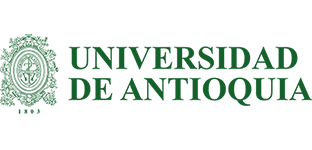

### **Universidad de Antioquia**

### **Facultad de Ingeniería**

### **Bioingeniería**

### **TEORÍA DE MODELOS Y SIMULACIÓN DE SISTEMAS**

---

# **Sesión 1: Introducción a Python**

## **Taller Práctico: Análisis de Señales en Bioingeniería**

**Semestre:** 2026 - 2

**Nombre:** Randy Garcia

**Documento:**

---

### **Objetivos**

- Aplicar los conceptos de generación, manipulación y visualización de señales en Python (NumPy y Matplotlib) a un caso simulado de Bioingeniería.

- Implementar estructuras de control de flujo (ciclos for) para el análisis punto a punto de señales.

- Construir funciones que integren la generación de señales, el análisis estadístico (RMS, correlación) y la representación gráfica de resultados.

- Interpretar los resultados obtenidos en el contexto de una aplicación biomédica real.

---


## **Ejercicio Propuesto**

**Contexto:** Un equipo de Bioingeniería de la Universidad de Antioquia está evaluando la fuerza de agarre (dinamometría) de dos voluntarios durante una prueba de resistencia muscular, con el fin de identificar los momentos en los que ambos presentan fatiga simultánea y caracterizar estadísticamente sus señales.

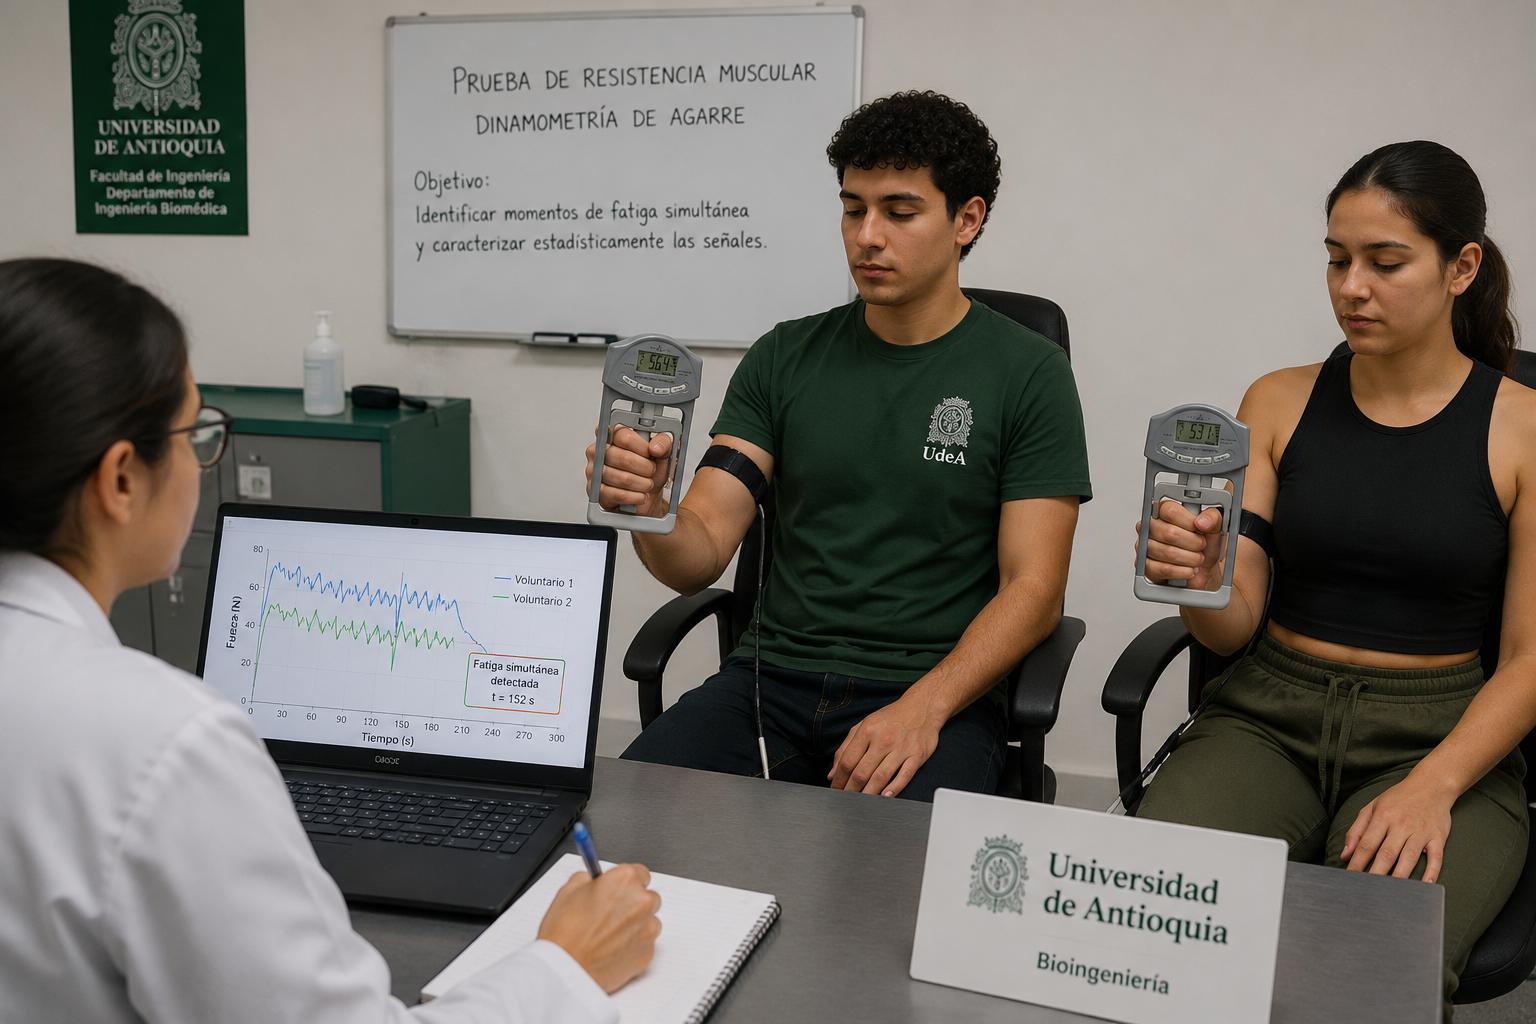

---

### **Importación de Librerías**

In [2]:
# Importe aquí las librerías necesarias para la solución del ejercicio.
import matplotlib.pyplot as plt
import numpy as np 

---
Elabore una función llamada **analisis_fatiga** que reciba como parámetros de entrada la amplitud y el período de la señal de cada voluntario (a1, t1, a2, t2) y un valor de umbral de fatiga, y que realice las siguientes tareas:

**A.** Cree el vector de tiempo considerando un total de 30 segundos con una frecuencia de muestreo de 10 muestras/segundo. Construya las señales senoidales de fuerza de cada voluntario, teniendo en cuenta que la amplitud ingresada se mantiene durante los primeros 15 segundos y decae a la mitad en los 15 segundos restantes (simulando el efecto de la fatiga sobre la fuerza máxima).

**B.** Utilice un ciclo **for** para recorrer ambas señales y determinar los instantes de tiempo en los que ambos voluntarios están simultáneamente por debajo del umbral de fatiga ingresado. Almacene dichos instantes, junto con los valores correspondientes de cada señal, en variables nuevas.

**C.** Calcule el valor RMS de cada señal usando la ecuación:

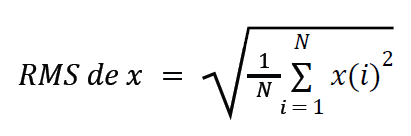

**D.** Calcule el coeficiente de correlación entre ambas señales usando np.corrcoef.

**E.** Construya una matriz de dimensión (2, N) que contenga los datos de ambos voluntarios (una fila por voluntario), usando **np.vstack**.

**F.** Grafique ambas señales en un mismo plano, resaltando con marcadores los instantes de fatiga simultánea encontrados en el numeral B, y trace una línea horizontal que represente el umbral. Incluya título, etiquetas de ejes y leyenda.

---

### **Solución**

# **PARTE 0**

Elabore una función llamada **analisis_fatiga** que reciba como parámetros de entrada la amplitud y el período de la señal de cada voluntario (a1, t1, a2, t2) y un valor de umbral de fatiga, y que realice las siguientes tareas:


In [ ]:
def analisi_fatiga(a1,t1,a2,t2,umbral):

    Tiempo_de_vector = 30 
    Frecuencia_muestreo = 10
    Periodo_muestreo = 1/Frecuencia_muestreo 
    vector_TIEMPO = np.arange(0,Tiempo_de_vector + Periodo_muestreo,Periodo_muestreo) #Este es para la grafica, para el eje X

    #Ahora es necesario saber que para crear la funcion senoidal se usa este mismo vector de tiempo para la formula.

    #Antes de eso pensemos en una cosa, la mejor forma para hacer que despues de 15 segundos la amplitud

     # F(t) = A(t) * sen(2*pi*f*t)
    f1 = 1/t1 #entonces el periodo que obtengo de la funcion es para saber la frecuencia del paciente
    Signal_1 = a1*np.sin(2*np.pi*f1*vector_TIEMPO)
    f2 = 1/t2
    Signal_2 = a2*np.sin(2*np.pi*f2*vector_TIEMPO)
    
   

analisi_fatiga(4,5,1,2,0)



[ 0.00000000e+00  5.01332934e-01  9.94759549e-01  1.47249821e+00
  1.92701470e+00  2.35114101e+00  2.73818842e+00  3.08205297e+00
  3.37731170e+00  3.61930821e+00  3.80422607e+00  3.92914900e+00
  3.99210691e+00  3.99210691e+00  3.92914900e+00  3.80422607e+00
  3.61930821e+00  3.37731170e+00  3.08205297e+00  2.73818842e+00
  2.35114101e+00  1.92701470e+00  1.47249821e+00  9.94759549e-01
  5.01332934e-01  4.89858720e-16 -5.01332934e-01 -9.94759549e-01
 -1.47249821e+00 -1.92701470e+00 -2.35114101e+00 -2.73818842e+00
 -3.08205297e+00 -3.37731170e+00 -3.61930821e+00 -3.80422607e+00
 -3.92914900e+00 -3.99210691e+00 -3.99210691e+00 -3.92914900e+00
 -3.80422607e+00 -3.61930821e+00 -3.37731170e+00 -3.08205297e+00
 -2.73818842e+00 -2.35114101e+00 -1.92701470e+00 -1.47249821e+00
 -9.94759549e-01 -5.01332934e-01 -9.79717439e-16  5.01332934e-01
  9.94759549e-01  1.47249821e+00  1.92701470e+00  2.35114101e+00
  2.73818842e+00  3.08205297e+00  3.37731170e+00  3.61930821e+00
  3.80422607e+00  3.92914

# **PARTE A**

**A.** Cree el vector de tiempo considerando un total de 30 segundos con una frecuencia de muestreo de 10 muestras/segundo. Construya las señales senoidales de fuerza de cada voluntario, teniendo en cuenta que la amplitud ingresada se mantiene durante los primeros 15 segundos y decae a la mitad en los 15 segundos restantes (simulando el efecto de la fatiga sobre la fuerza máxima).

## Explicación teórica

Para construir las señales de fuerza primero se debe crear un vector de tiempo de **30 segundos**, teniendo en cuenta una frecuencia de muestreo de **10 muestras por segundo**. Esto significa que se obtiene una muestra cada **0.1 segundos**.

La señal de fuerza se representa mediante una función senoidal, donde la **amplitud** representa la fuerza máxima del voluntario y la **frecuencia** determina qué tan rápido oscila la señal.

Para simular el efecto de la **fatiga**, se considera que durante los primeros **15 segundos** el voluntario mantiene su amplitud original. A partir de los 15 segundos, la amplitud disminuye al **50 % de su valor inicial**. De esta manera, la señal mantiene su comportamiento senoidal, pero su magnitud disminuye durante la segunda mitad del experimento.

En términos matemáticos, la amplitud cambia de acuerdo con:

[
A(t)=
\begin{cases}
A, & 0 \leq t < 15\
A/2, & 15 \leq t \leq 30
\end{cases}
]

Esto permite representar de manera sencilla la pérdida de fuerza máxima producida por la fatiga a lo largo del tiempo.


In [ ]:
# Inserte aquí la solución del ejercicio propuesto.

##Punto A

# ---------------------------------------------------------
# 1. DATOS INICIALES
# ---------------------------------------------------------

# Frecuencia de muestreo:
# significa que tomaremos 10 muestras cada segundo
fs = 10

# Tiempo total del experimento en segundos
tiempo_total = 30

# Creamos el vector de tiempo.
# Como tenemos 10 muestras por segundo, cada muestra está
# separada por 1/10 = 0.1 segundos.
t = np.arange(0, tiempo_total, 1/fs) #Aqui lo que se muestra es el periodo al final ya que es la inversa de la frecuencia.
print(t)

# ---------------------------------------------------------
# 2. DATOS DE LOS VOLUNTARIOS
# ---------------------------------------------------------

# Amplitud inicial de la fuerza de cada voluntario.
# Estos valores son ejemplos y se pueden cambiar por los
# valores que indique el ejercicio.
amplitudes = [100, 120, 90]

# Frecuencia de la señal de cada voluntario.
frecuencias = [1, 1, 1]


# ---------------------------------------------------------
# 3. CONSTRUCCIÓN DE LAS SEÑALES
# ---------------------------------------------------------

# Recorremos los tres voluntarios.
for i in range(3):

    # Obtenemos la amplitud del voluntario actual
    amplitud = amplitudes[i]

    # Obtenemos la frecuencia del voluntario actual
    frecuencia = frecuencias[i]

    # Durante los primeros 15 segundos se mantiene la
    # amplitud original.
    #
    # Después de los 15 segundos, la amplitud disminuye
    # hasta la mitad para representar el efecto de la fatiga.
    amplitud_actual = np.where(t < 15, amplitud, amplitud / 2)

    # Construimos la señal senoidal de fuerza.
    #
    # La ecuación utilizada es:
    # F(t) = A(t) * sen(2*pi*f*t)
    #
    # Donde A(t) es la amplitud que cambia debido a la fatiga.
    fuerza = amplitud_actual * np.sin(2 * np.pi * frecuencia * t)

    # Dibujamos la señal del voluntario
    plt.plot(t, fuerza, label=f'Voluntario {i + 1}')


# ---------------------------------------------------------
# 4. CONFIGURACIÓN DE LA GRÁFICA
# ---------------------------------------------------------

# Nombre del eje horizontal
plt.xlabel('Tiempo (s)')

# Nombre del eje vertical
plt.ylabel('Fuerza')

# Título de la gráfica
plt.title('Señales de fuerza de los voluntarios')

# Muestra el nombre de cada señal
plt.legend()

# Agregamos una cuadrícula para facilitar la lectura
plt.grid()

# Mostramos la gráfica
plt.show()


### ¿Qué hace el código?

##El código primero crea el **vector de tiempo de 30 segundos** utilizando una frecuencia de muestreo de 10 Hz. Después, para cada voluntario, toma su amplitud y frecuencia y construye una señal senoidal.

#La parte más importante es:


amplitud_actual = np.where(t < 15, amplitud, amplitud / 2)


#Esta instrucción hace que la amplitud sea **normal durante los primeros 15 segundos** y pase a ser **la mitad durante los últimos 15 segundos**. Finalmente, esa amplitud se utiliza en la ecuación de la señal senoidal para representar el efecto de la fatiga.



In [ ]:
##CODIGO COMPLETO

import numpy as np
import matplotlib.pyplot as plt


def analisis_fatiga(a1, t1, a2, t2, umbral):
    
    # =========================================================
    # A. CREACIÓN DEL VECTOR DE TIEMPO Y DE LAS SEÑALES
    # =========================================================
    
    # La frecuencia de muestreo es de 10 muestras por segundo.
    # Esto significa que tenemos una muestra cada 0.1 segundos.
    fs = 10
    
    # El experimento tiene una duración total de 30 segundos.
    tiempo_total = 30
    
    # Creamos el vector de tiempo desde 0 hasta antes de 30 segundos.
    # El paso entre cada muestra es 1/fs = 0.1 segundos.
    tiempo = np.arange(0, tiempo_total, 1/fs)
    
    
    # ---------------------------------------------------------
    # Señal del voluntario 1
    # ---------------------------------------------------------
    
    # Durante los primeros 15 segundos se mantiene la amplitud
    # ingresada por el usuario.
    #
    # Después de los 15 segundos, la amplitud disminuye a la
    # mitad para representar el efecto de la fatiga.
    amplitud1 = np.where(tiempo < 15, a1, a1 / 2)
    
    # La frecuencia de una señal se obtiene como:
    #
    # frecuencia = 1 / período
    #
    # Por eso utilizamos el período ingresado t1.
    frecuencia1 = 1 / t1
    
    # Construimos la señal senoidal del voluntario 1:
    #
    # F(t) = A(t) * sen(2*pi*f*t)
    fuerza1 = amplitud1 * np.sin(2 * np.pi * frecuencia1 * tiempo)
    
    
    # ---------------------------------------------------------
    # Señal del voluntario 2
    # ---------------------------------------------------------
    
    # Aplicamos exactamente el mismo procedimiento al segundo
    # voluntario, utilizando su amplitud y período.
    amplitud2 = np.where(tiempo < 15, a2, a2 / 2)
    
    frecuencia2 = 1 / t2
    
    fuerza2 = amplitud2 * np.sin(2 * np.pi * frecuencia2 * tiempo)
    
    
    # =========================================================
    # B. BÚSQUEDA DE FATIGA SIMULTÁNEA
    # =========================================================
    
    # Creamos listas vacías para guardar los resultados.
    #
    # Aquí almacenaremos:
    # - Los instantes donde ambos están por debajo del umbral.
    # - El valor de fuerza del voluntario 1.
    # - El valor de fuerza del voluntario 2.
    tiempos_fatiga = []
    fuerza1_fatiga = []
    fuerza2_fatiga = []
    
    
    # Recorremos las dos señales utilizando un ciclo for.
    # "i" representa la posición actual dentro de las señales.
    for i in range(len(tiempo)):
        
        # Comprobamos si AMBOS voluntarios están por debajo
        # del umbral de fatiga en el mismo instante.
        if fuerza1[i] < umbral and fuerza2[i] < umbral:
            
            # Guardamos el instante de tiempo.
            tiempos_fatiga.append(tiempo[i])
            
            # Guardamos la fuerza correspondiente del voluntario 1.
            fuerza1_fatiga.append(fuerza1[i])
            
            # Guardamos la fuerza correspondiente del voluntario 2.
            fuerza2_fatiga.append(fuerza2[i])
    
    
    # Convertimos las listas en arreglos de NumPy para poder
    # trabajar fácilmente con ellos posteriormente.
    tiempos_fatiga = np.array(tiempos_fatiga)
    fuerza1_fatiga = np.array(fuerza1_fatiga)
    fuerza2_fatiga = np.array(fuerza2_fatiga)
    
    
    # =========================================================
    # C. CÁLCULO DEL VALOR RMS
    # =========================================================
    
    # El RMS (Root Mean Square) permite obtener un valor que
    # representa la magnitud efectiva de una señal.
    #
    # La ecuación es:
    #
    # RMS = sqrt( (x1^2 + x2^2 + ... + xn^2) / N )
    #
    # Primero elevamos cada valor al cuadrado, calculamos
    # el promedio y finalmente obtenemos la raíz cuadrada.
    
    rms1 = np.sqrt(np.mean(fuerza1 ** 2))
    rms2 = np.sqrt(np.mean(fuerza2 ** 2))
    
    
    # =========================================================
    # D. COEFICIENTE DE CORRELACIÓN
    # =========================================================
    
    # np.corrcoef calcula la matriz de correlación entre
    # las dos señales.
    #
    # La posición [0,1] contiene la correlación entre
    # la señal del voluntario 1 y la del voluntario 2.
    correlacion = np.corrcoef(fuerza1, fuerza2)[0, 1]
    
    
    # =========================================================
    # E. MATRIZ DE DATOS
    # =========================================================
    
    # np.vstack permite colocar los dos vectores uno debajo
    # del otro.
    #
    # El resultado tendrá dimensión (2, N):
    #   - Primera fila: señal del voluntario 1
    #   - Segunda fila: señal del voluntario 2
    datos = np.vstack((fuerza1, fuerza2))
    
    
    # =========================================================
    # F. GRÁFICA
    # =========================================================
    
    # Graficamos las dos señales en el mismo plano.
    plt.plot(tiempo, fuerza1, label='Voluntario 1')
    plt.plot(tiempo, fuerza2, label='Voluntario 2')
    
    # Resaltamos con marcadores los puntos donde ambos
    # voluntarios están simultáneamente por debajo del umbral.
    plt.plot(
        tiempos_fatiga,
        fuerza1_fatiga,
        'o',
        label='Fatiga simultánea'
    )
    
    plt.plot(
        tiempos_fatiga,
        fuerza2_fatiga,
        'o'
    )
    
    # Dibujamos una línea horizontal que representa
    # el umbral de fatiga.
    plt.axhline(
        y=umbral,
        linestyle='--',
        label='Umbral de fatiga'
    )
    
    # Nombre de los ejes.
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Fuerza')
    
    # Título de la gráfica.
    plt.title('Análisis de fatiga de los voluntarios')
    
    # Mostramos la leyenda para identificar cada elemento.
    plt.legend()
    
    # Agregamos una cuadrícula para facilitar la lectura.
    plt.grid()
    
    # Mostramos la gráfica.
    plt.show()
    
    
    # =========================================================
    # RESULTADOS
    # =========================================================
    
    # Retornamos los resultados principales de la función
    # para poder utilizarlos posteriormente.
    return (
        tiempo,
        fuerza1,
        fuerza2,
        tiempos_fatiga,
        fuerza1_fatiga,
        fuerza2_fatiga,
        rms1,
        rms2,
        correlacion,
        datos
    )

### Explicación de la lógica

# La función recibe únicamente los **datos de entrada**:

# ```python
# a1, t1, a2, t2, umbral
# ```

# donde `a1` y `a2` son las amplitudes, `t1` y `t2` son los períodos y `umbral` es el límite utilizado para determinar la fatiga.

# Primero se construye el vector de tiempo con una frecuencia de muestreo de **10 Hz** durante **30 segundos**. Después se construye cada señal como una senoide. Para representar la fatiga, la amplitud utilizada es la original durante los primeros 15 segundos y la mitad durante los 15 segundos restantes.

# En el numeral **B** se utiliza explícitamente un `for`, como solicita el ejercicio. En cada instante se comprueba la condición:

# ```python
# if fuerza1[i] < umbral and fuerza2[i] < umbral:
# ```

# El `and` es importante porque queremos encontrar únicamente los momentos en los que **los dos voluntarios están simultáneamente por debajo del umbral**.

# Después se calculan los valores **RMS**, que representan la magnitud efectiva de cada señal, y se obtiene la correlación mediante `np.corrcoef`. Finalmente, `np.vstack` organiza ambas señales en una matriz de dos filas y se genera la gráfica con las señales, el umbral y los puntos donde ocurre fatiga simultánea.


---

### **Análisis del Ejercicio Propuesto**

Adicionalmente, responda:

* ¿Por qué la amplitud decae a partir de los 15 segundos y qué representa esto fisiológicamente?

* ¿Qué indica un coeficiente de correlación cercano a 0 entre las dos señales?

**Inserte aquí sus respuestas**

---

### **Pista del Resultado Esperado**

*(Para verificar, como ejemplo de la implementación de la función)*.

Al ejecutar **analisis_fatiga(5, 6, 4, 8, 2)** se debe obtener, impreso en pantalla:

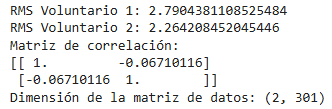

Y una gráfica con dos señales senoidales que tienen mayor amplitud en los primeros 15 segundos y luego se reducen a la mitad, una línea horizontal negra en y = 2 marcando el umbral, y marcadores rojos (x) y verdes (o) agrupados en los tramos donde ambas curvas caen simultáneamente por debajo de esa línea (se generan 171 coincidencias en total con estos parámetros). Así:

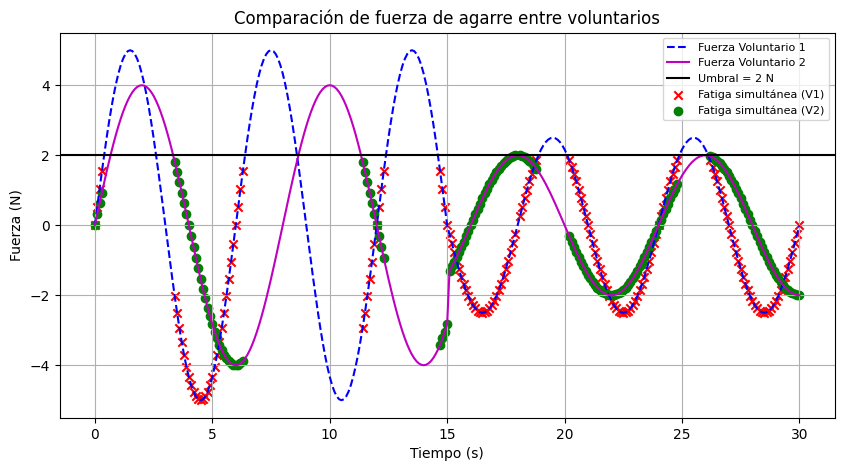

